## Mount Drive

In [156]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing the relevant libraries

In [157]:
pip install feature-engine

In [158]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings, gc, joblib
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, PassiveAggressiveRegressor, SGDRegressor, HuberRegressor, Lasso, Ridge, ElasticNet, BayesianRidge, PoissonRegressor, ARDRegression, RANSACRegressor, GammaRegressor, TweedieRegressor, TheilSenRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, BaggingRegressor, VotingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor, XGBRFRegressor
from lightgbm import LGBMRegressor
from scipy.stats import probplot
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer, PowerTransformer
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import SelectKBest, SelectPercentile, SelectFromModel, f_regression, SequentialFeatureSelector, RFE
from yellowbrick.regressor import PredictionError, ResidualsPlot
from sklearn.pipeline import Pipeline

## Loading the dataset

In [159]:
df = pd.read_csv('/content/drive/MyDrive/ML/DataMining/تمرین سوم/Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Data Exploration

In [160]:
df.shape

(2938, 22)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [162]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [163]:
df.isna().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [164]:
df.duplicated().sum()

np.int64(0)

In [165]:
df.nunique()

,0
Country,193
Year,16
Status,2
Life expectancy,362
Adult Mortality,425
infant deaths,209
Alcohol,1076
percentage expenditure,2328
Hepatitis B,87
Measles,958


In [166]:
df.rename({'Life expectancy ': 'Life Expectancy',
           'infant deaths': 'Infant Deaths',
           'percentage expenditure': 'Percentage Expenditure',
           'Measles ': 'Measles',
           ' BMI ': 'BMI',
           'under-five deaths ': 'Under-Five Deaths',
           'Total expenditure': 'Total Expenditure',
           'Diphtheria ': 'Diphtheria',
           ' HIV/AIDS': 'HIV/AIDS',
           ' thinness  1-19 years': 'Thinness 1-19 Years',
           ' thinness 5-9 years': 'Thinness 5-9 Years',
           'Income composition of resources': 'Income Composition of Resources'},axis=1,inplace=True)

## Exploratory Data Analysis

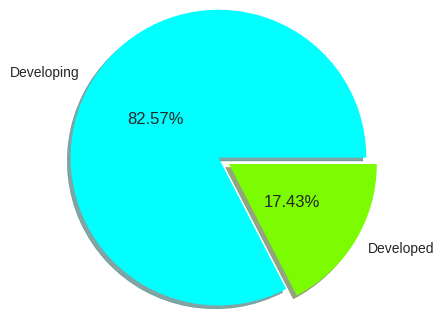

In [167]:
labels = df.Status.value_counts().keys()
values = df.Status.value_counts().values

plt.figure(figsize=(7,4))
plt.pie(values,labels=labels,explode=(0.1,0),shadow=True,autopct='%1.2f%%',pctdistance=0.5,radius=1.2,colors=['aqua','lawngreen'])
plt.show();

A significant number of nations are developing with just over 17% countries being developed.

In [168]:
#for col in df.select_dtypes(np.number).columns:
#    print(f"Skewness of {col}:",df[col].skew())
#    print(f"Kurtosis of {col}:",df[col].kurtosis())
#    plt.figure(figsize=(14,4))
#    plt.subplot(131)
#    sns.distplot(df[col])
#    plt.subplot(132)
#    sns.boxplot(df[col])
#    plt.subplot(133)
#    probplot(df[col],plot=plt,dist='norm',rvalue=True)
#    plt.suptitle(col)
#    plt.show()
#    gc.collect();

In [169]:
skewed_cols = ['Life Expectancy','Adult Mortality','Infant Deaths','Percentage Expenditure','Hepatitis B','Measles','Under-Five Deaths','Polio','Total Expenditure','Diphtheria','HIV/AIDS','GDP','Population','Thinness 1-19 Years','Thinness 5-9 Years','Income Composition of Resources','Schooling']
skewed_cols

['Life Expectancy',
 'Adult Mortality',
 'Infant Deaths',
 'Percentage Expenditure',
 'Hepatitis B',
 'Measles',
 'Under-Five Deaths',
 'Polio',
 'Total Expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'Thinness 1-19 Years',
 'Thinness 5-9 Years',
 'Income Composition of Resources',
 'Schooling']

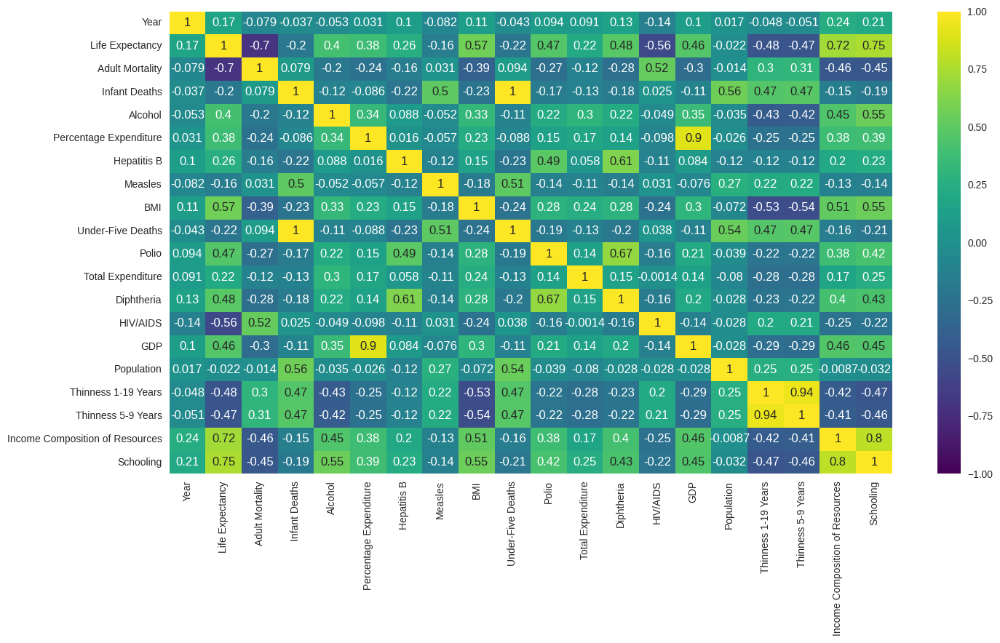

In [170]:
plt.figure(figsize=(15,9))
#fig = sns.heatmap(df.corr(),annot=True,cmap='viridis',vmin=-1.0,vmax=1.0)
fig = sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='viridis',vmin=-1.0,vmax=1.0)
plt.tight_layout()
plt.show(fig)
plt.close('all')
del fig
gc.collect();

## Feature Engineering

### Missing Values Imputation

In [171]:
missing_val_cols = df.columns[df.isnull().any()]
imputer = KNNImputer()

for col in missing_val_cols:
    df[col] = imputer.fit_transform(df[[col]])

In [172]:
df.isna().sum()

,0
Country,0
Year,0
Status,0
Life Expectancy,0
Adult Mortality,0
Infant Deaths,0
Alcohol,0
Percentage Expenditure,0
Hepatitis B,0
Measles,0


### Feature Transformation

In [173]:
def apply_transform(transformer,col):
    plt.figure(figsize=(14,4))
    plt.subplot(131)
    sns.distplot(df[col])
    plt.subplot(132)
    sns.boxplot(df[col])
    plt.subplot(133)
    probplot(df[col],rvalue=True,dist='norm',plot=plt)
    plt.suptitle(f"{col} Before Transform")
    plt.show()
    col_tf = transformer.fit_transform(df[[col]])
    col_tf = np.array(col_tf).reshape(col_tf.shape[0])
    plt.figure(figsize=(14,4))
    plt.subplot(131)
    sns.distplot(col_tf)
    plt.subplot(132)
    sns.boxplot(col_tf)
    plt.subplot(133)
    probplot(col_tf,rvalue=True,dist='norm',plot=plt)
    plt.suptitle(f"{col} After Transform")
    plt.show()
    gc.collect();

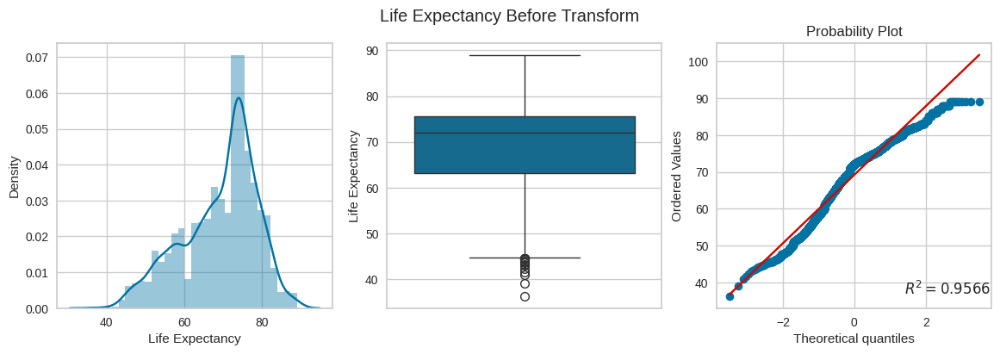

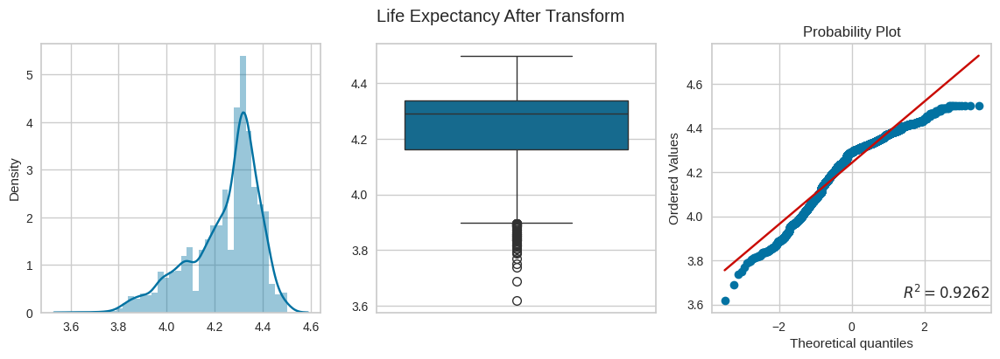

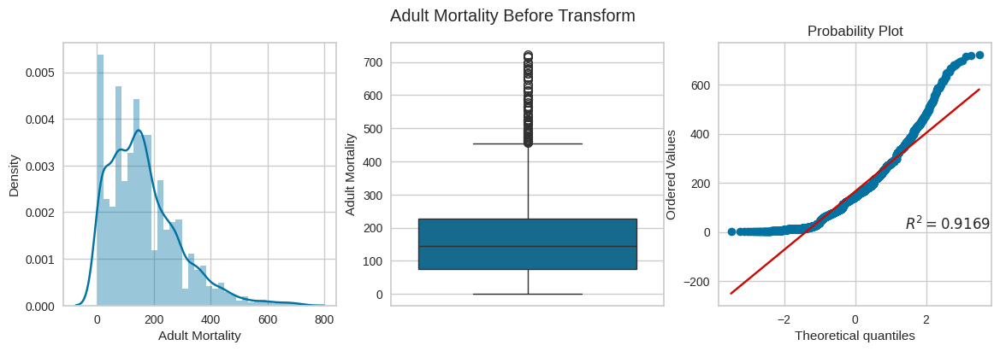

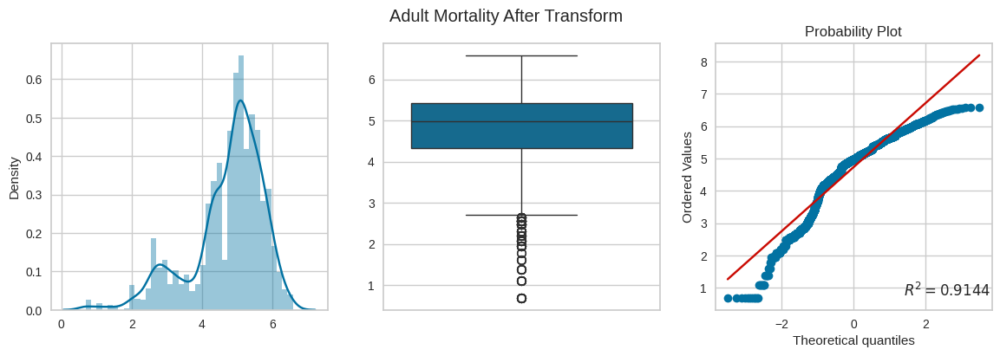

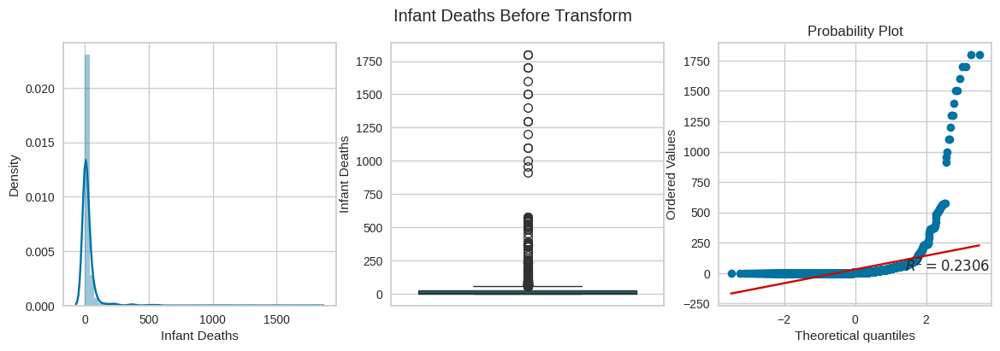

...

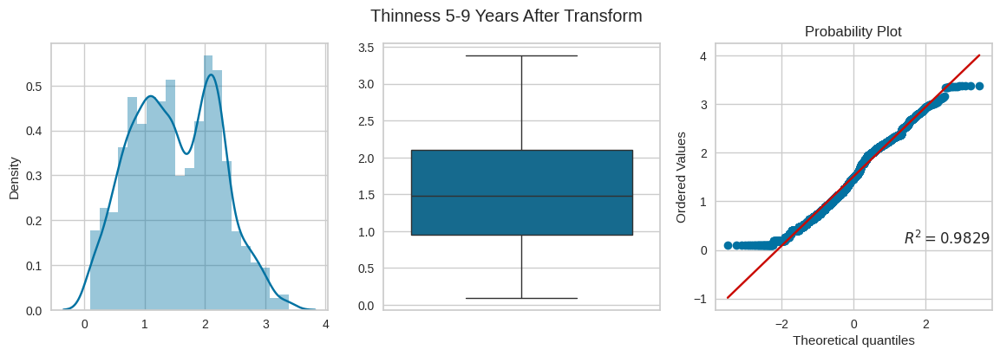

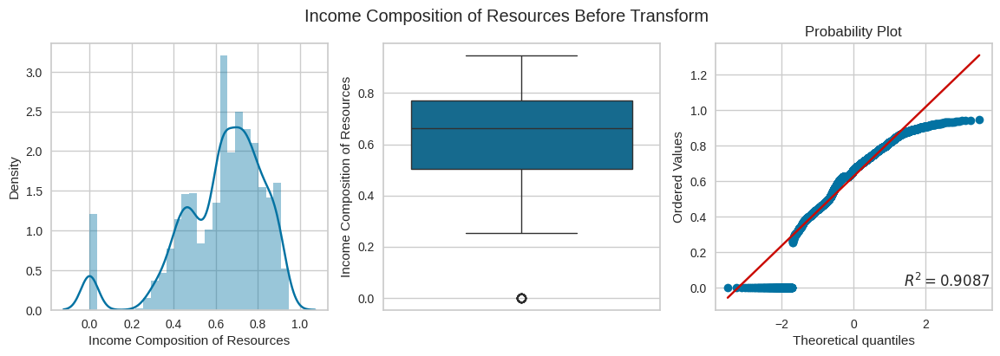

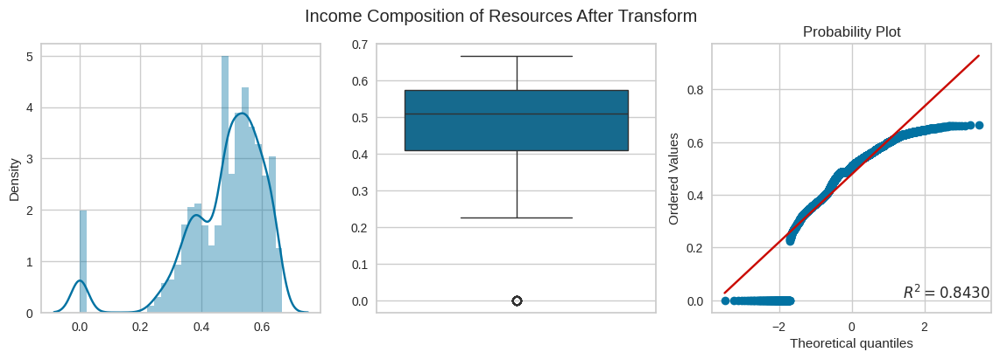

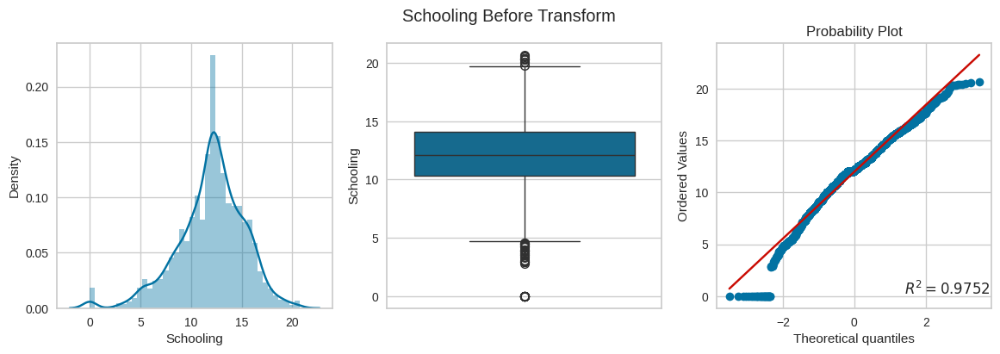

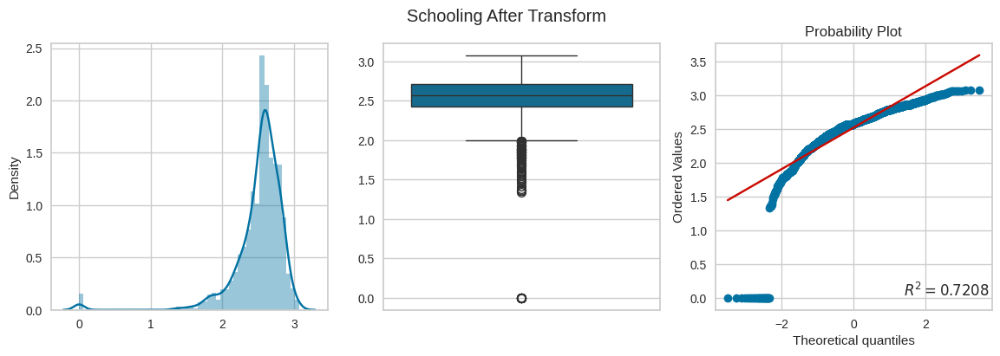

In [174]:
# Log Transform
for col in skewed_cols:
    apply_transform(FunctionTransformer(np.log1p),col)

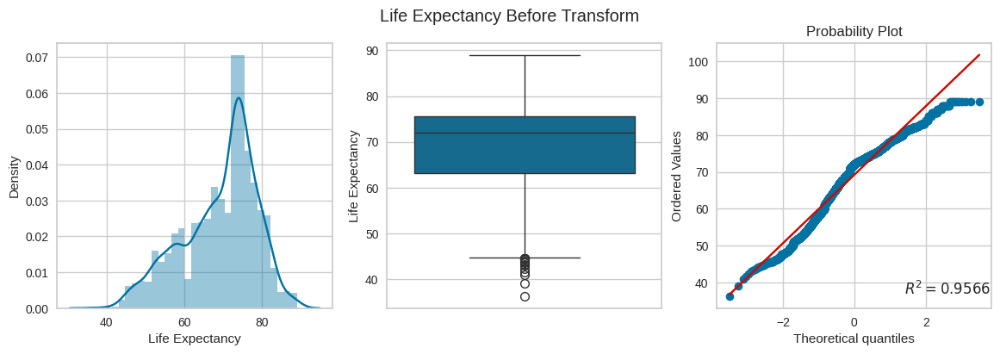

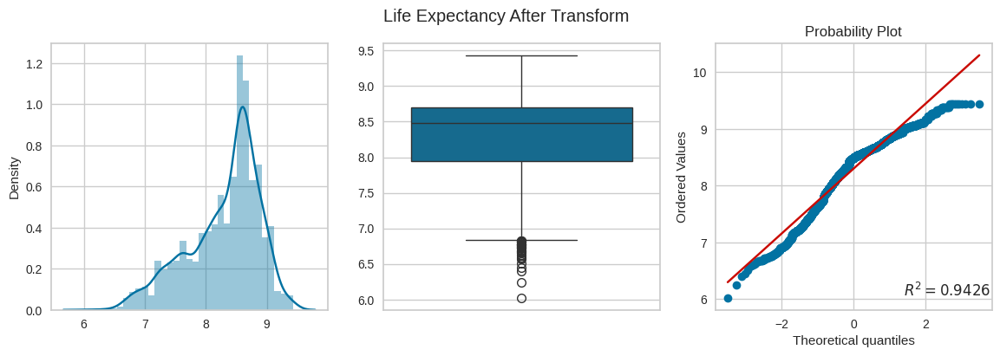

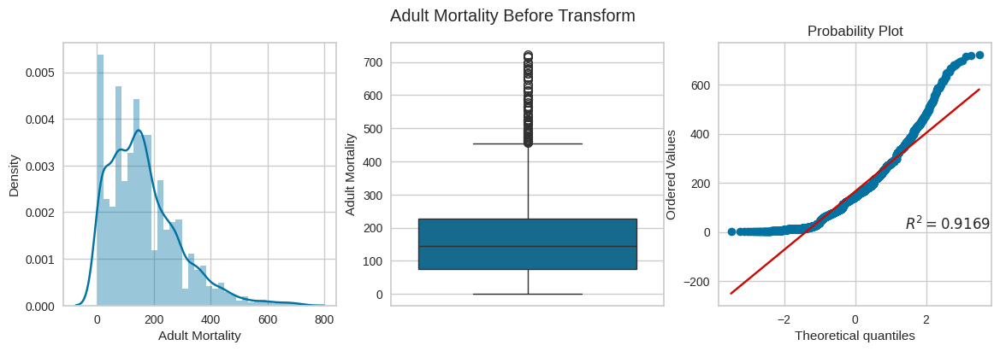

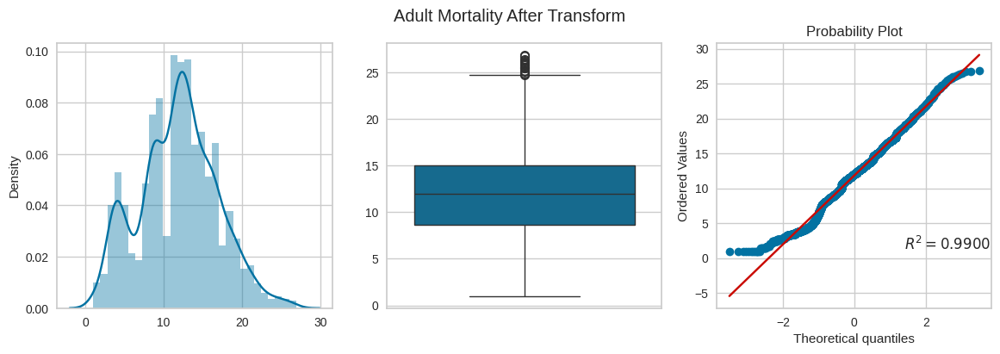

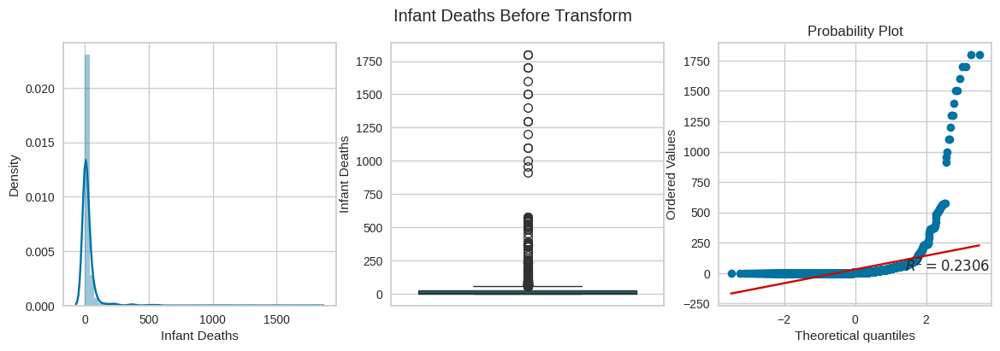

...

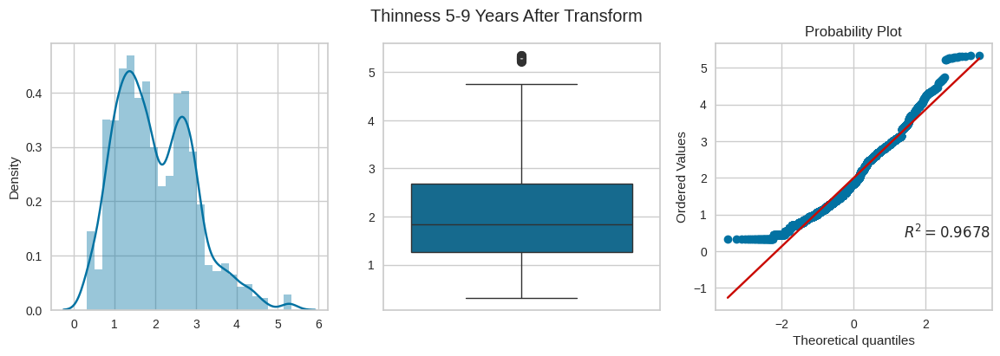

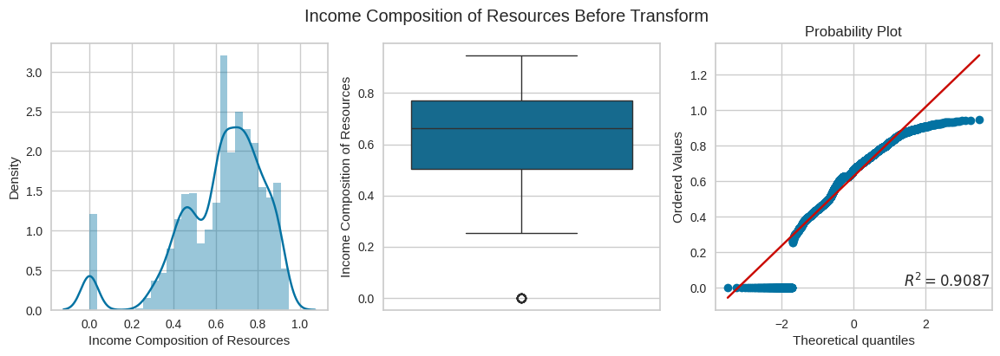

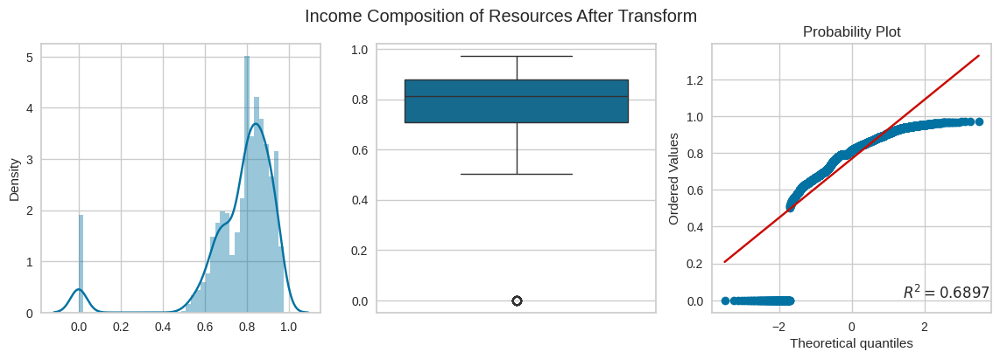

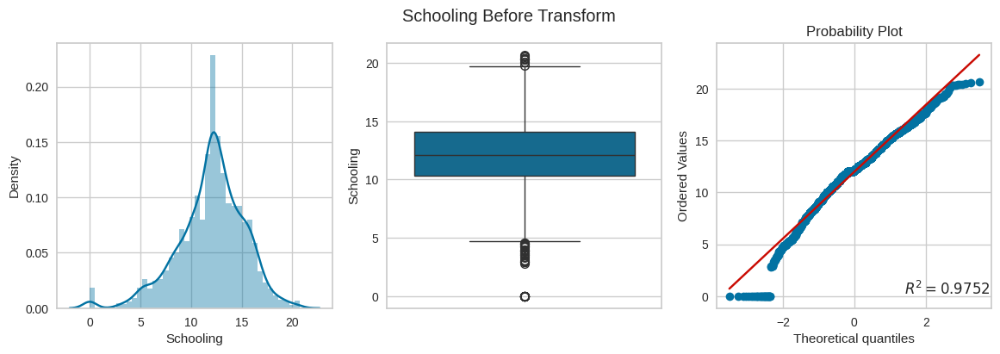

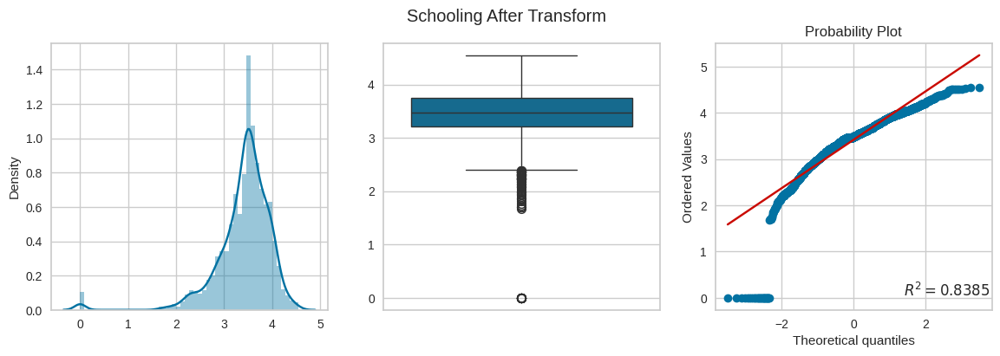

In [175]:
# Square Root Transform
for col in skewed_cols:
    apply_transform(FunctionTransformer(np.sqrt),col)

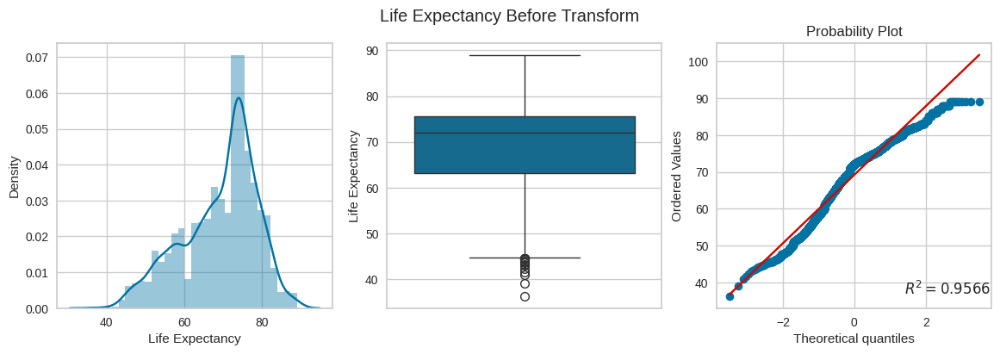

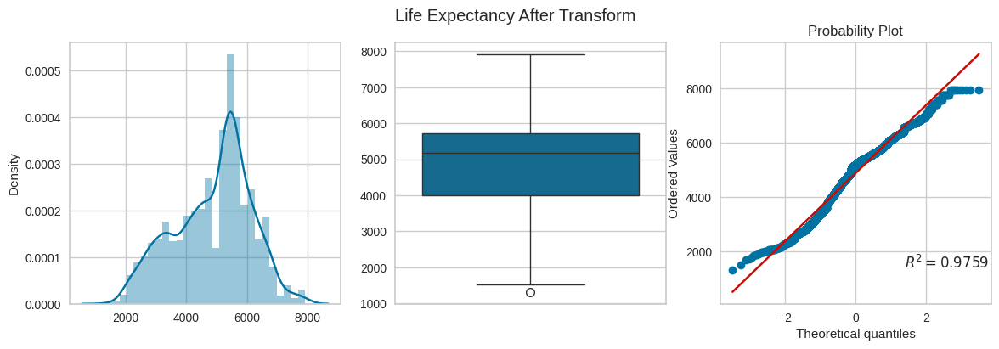

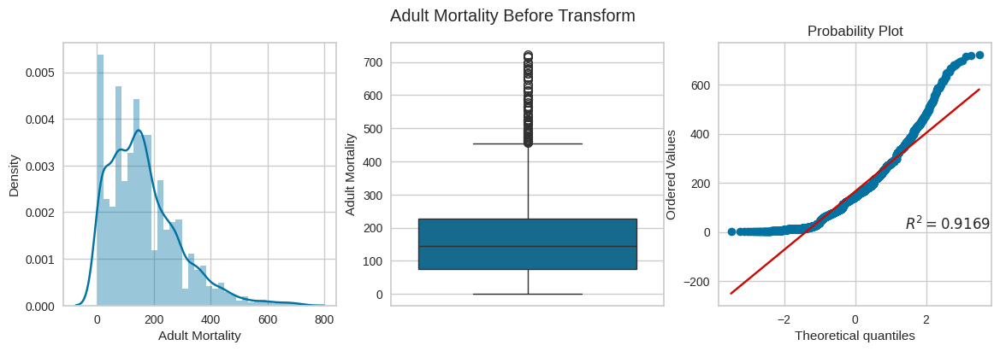

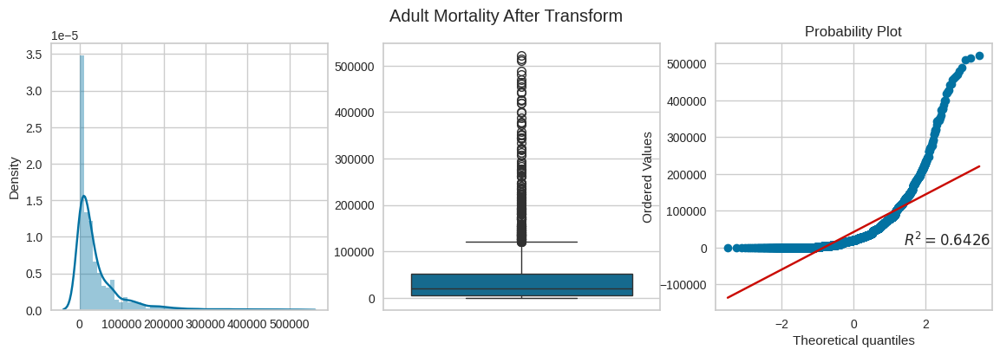

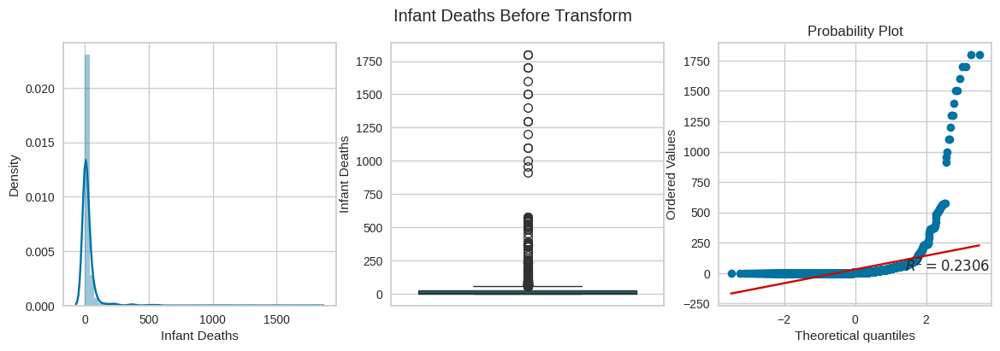

...

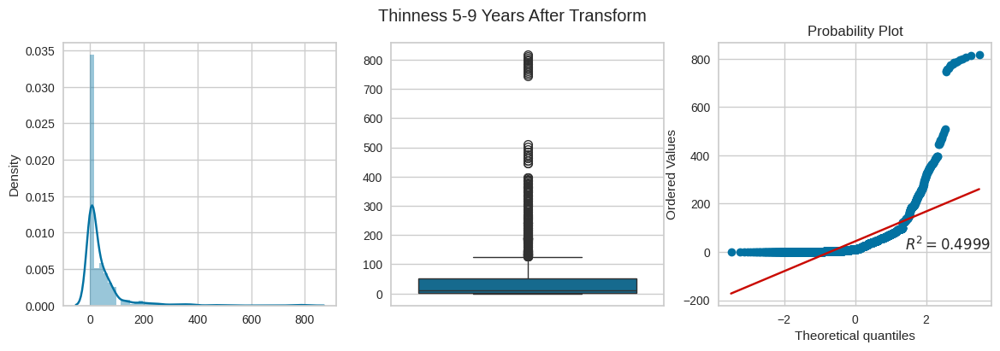

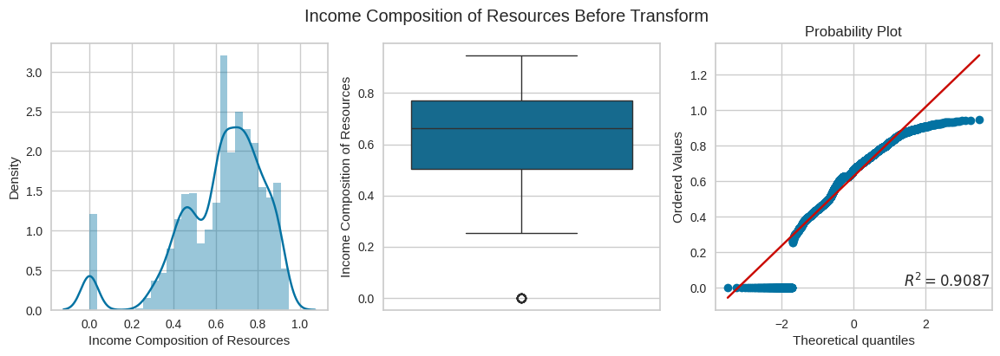

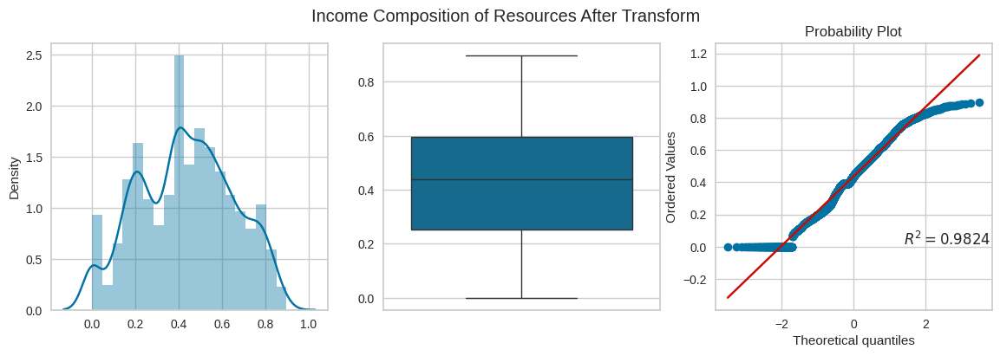

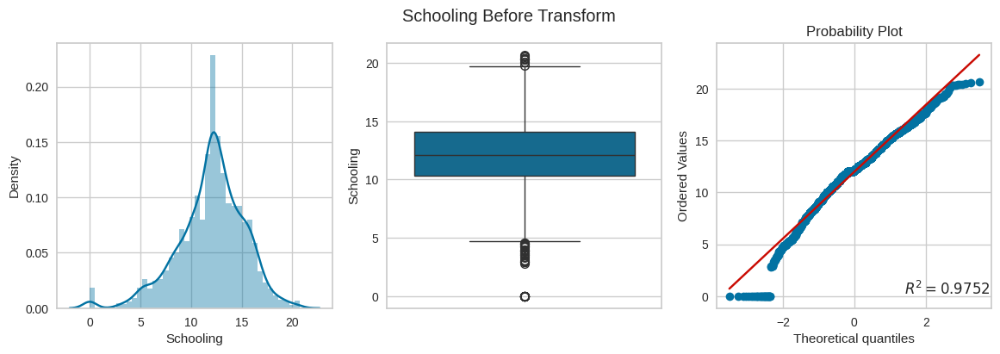

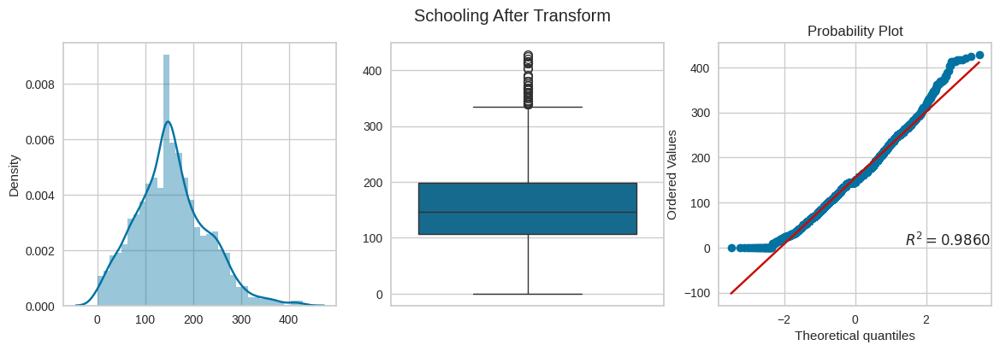

In [176]:
# Square Transform
for col in skewed_cols:
    apply_transform(FunctionTransformer(np.square),col)

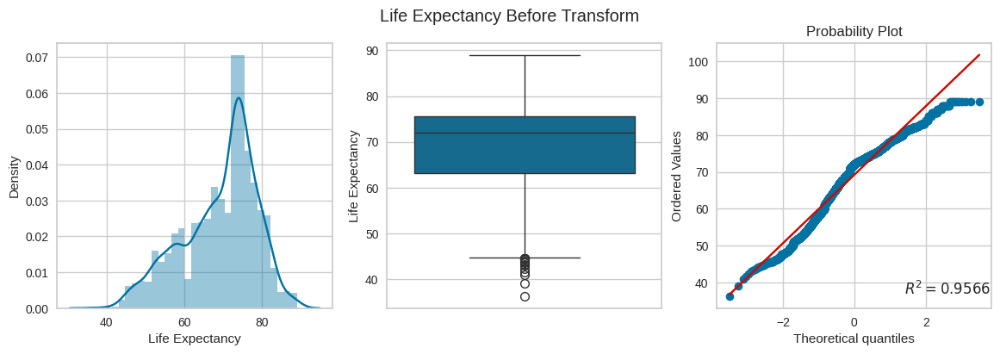

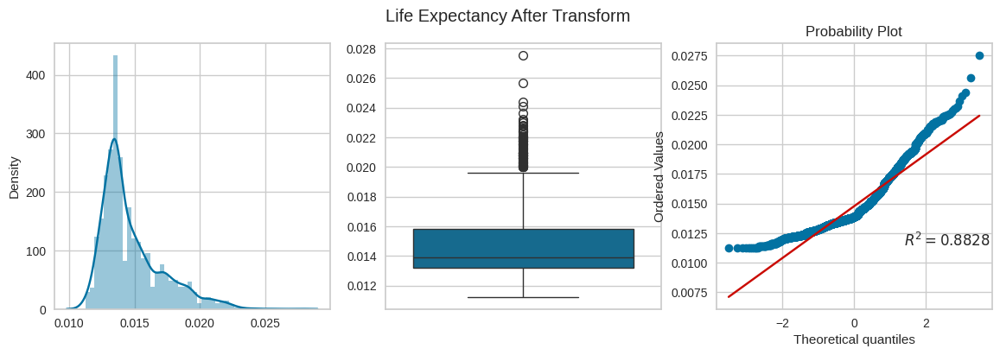

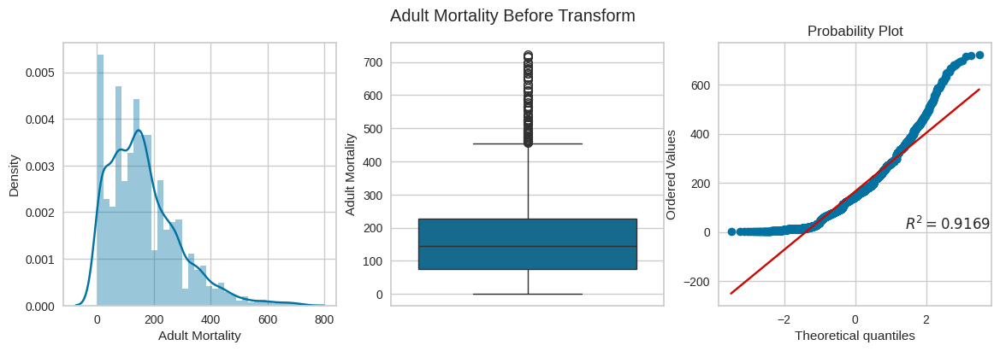

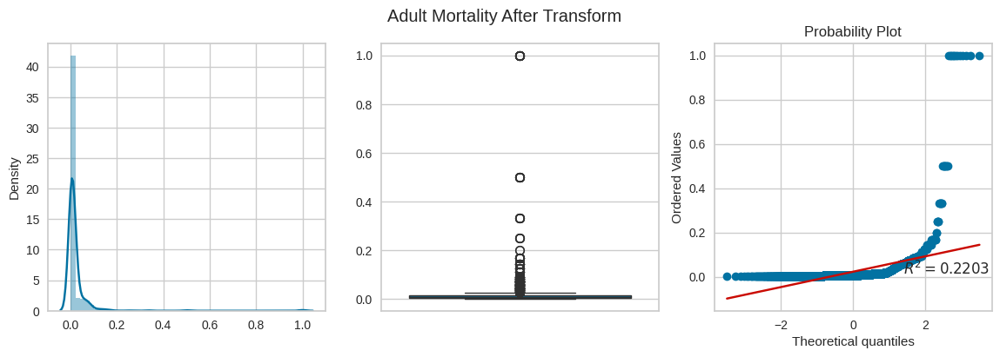

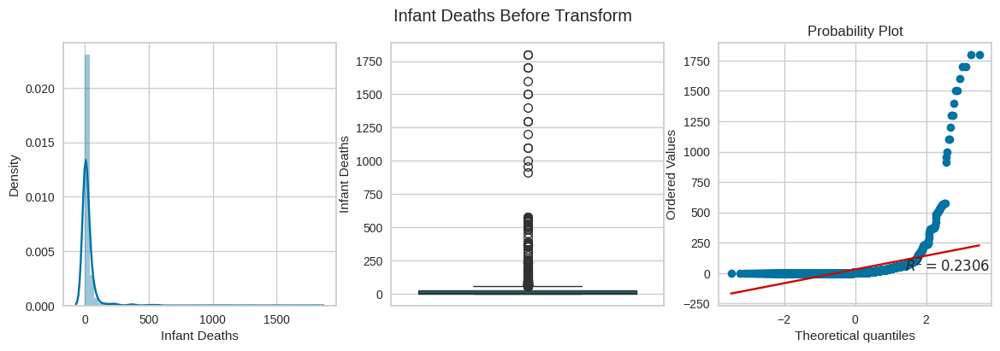

...

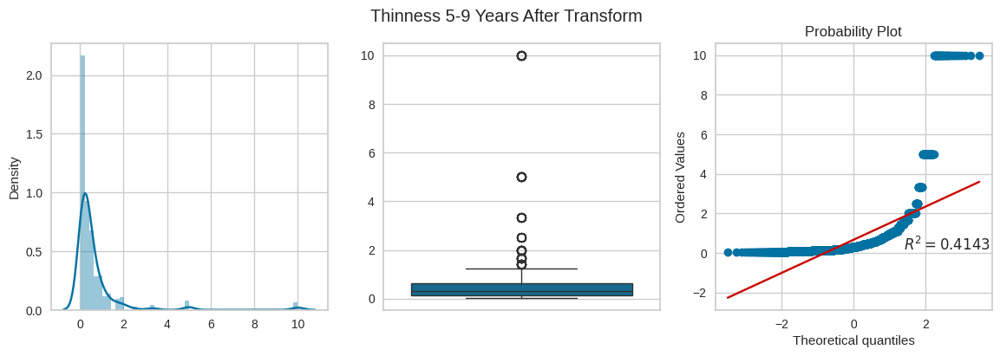

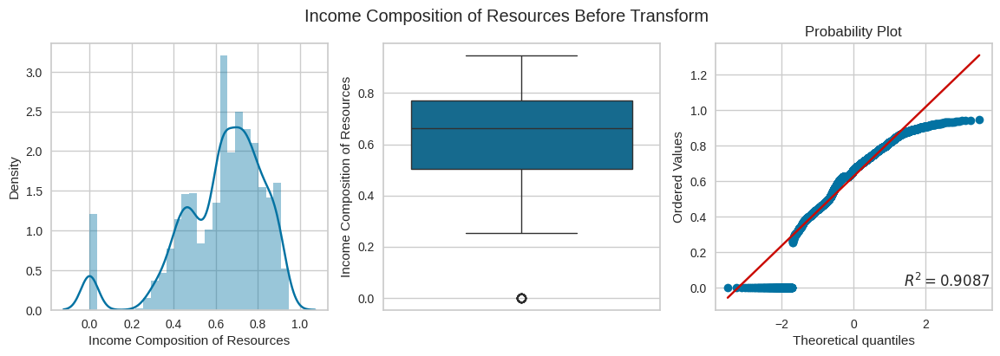

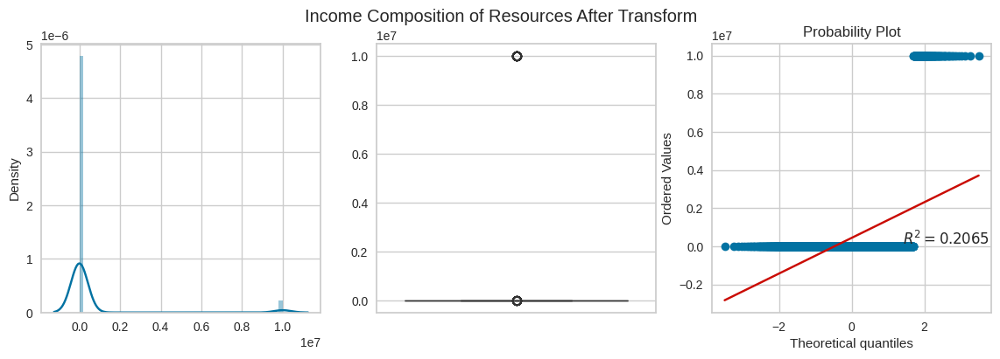

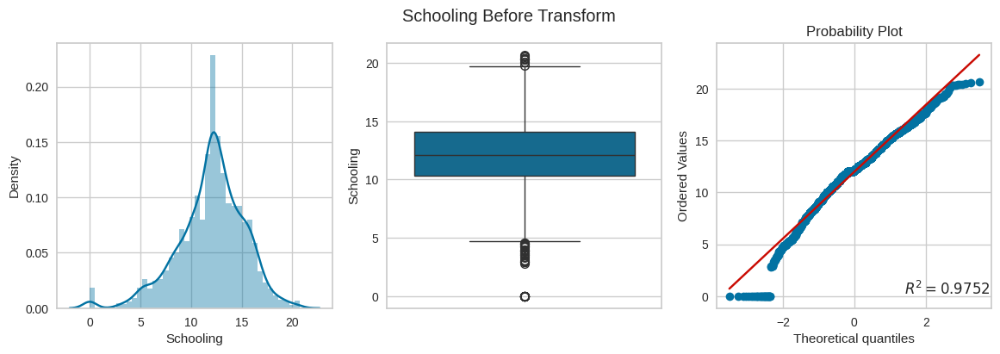

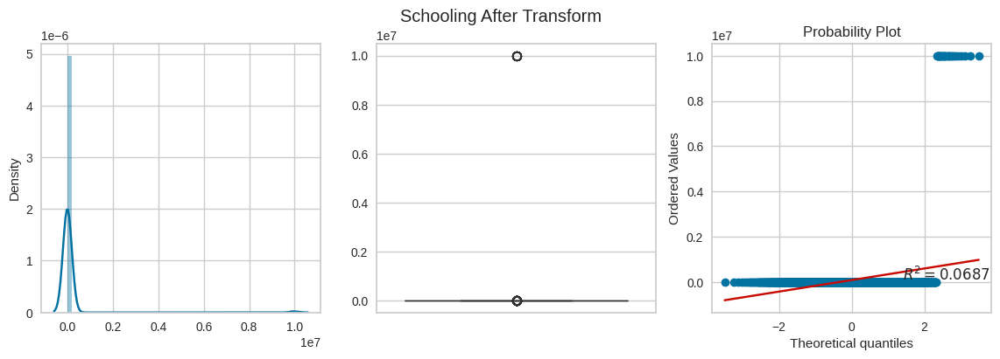

In [177]:
# Reciprocal Transform
for col in skewed_cols:
    apply_transform(FunctionTransformer(lambda x: 1/(x+0.0000001)),col)

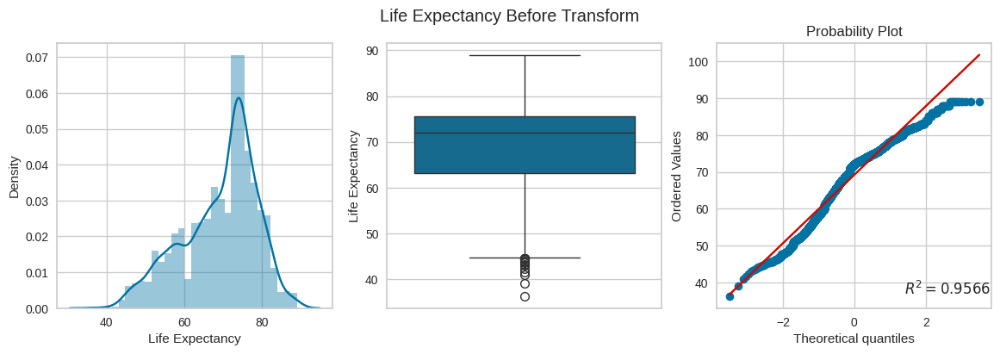

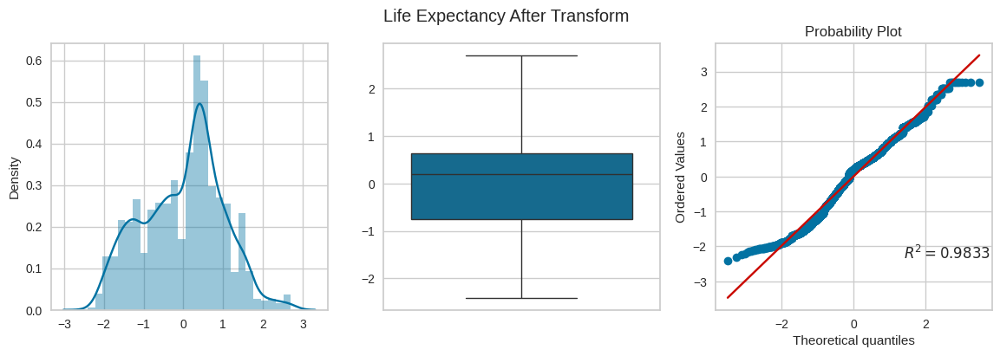

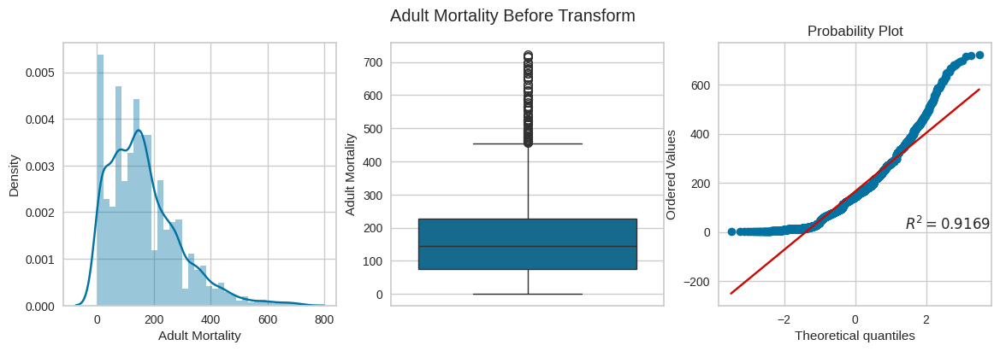

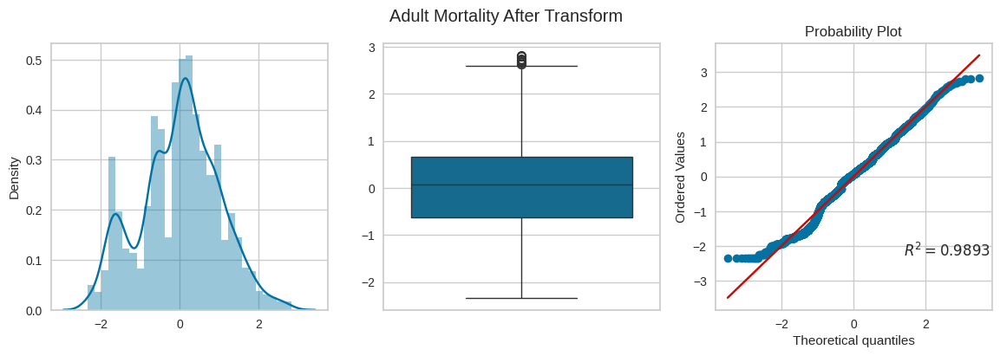

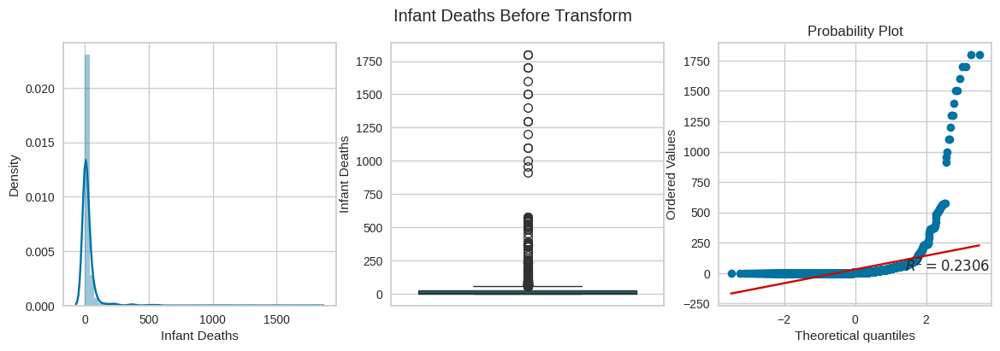

...

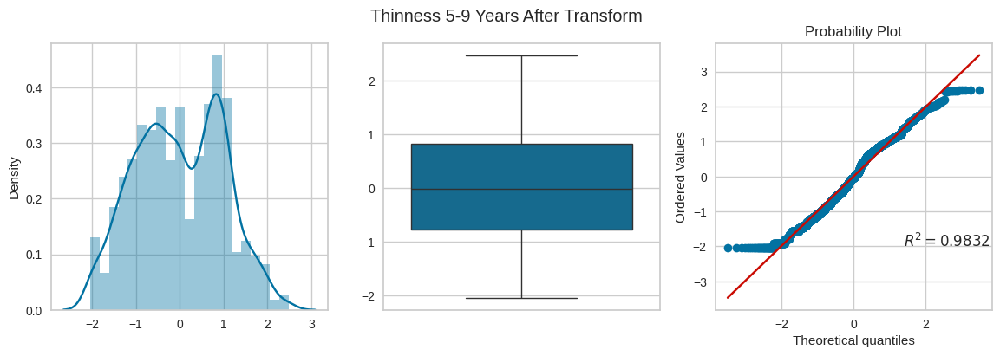

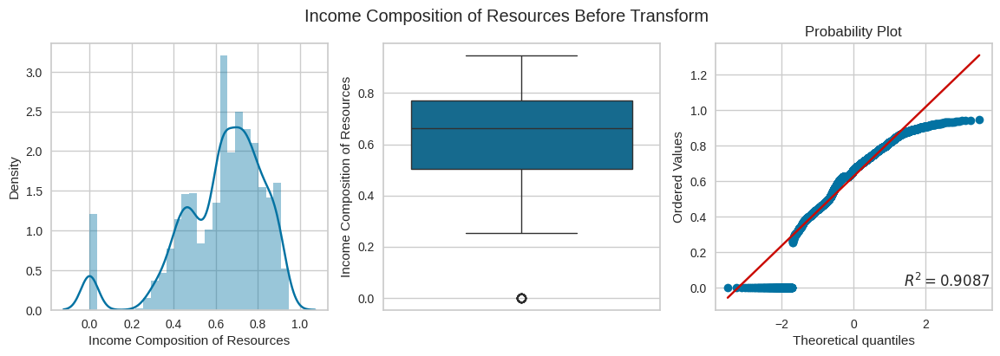

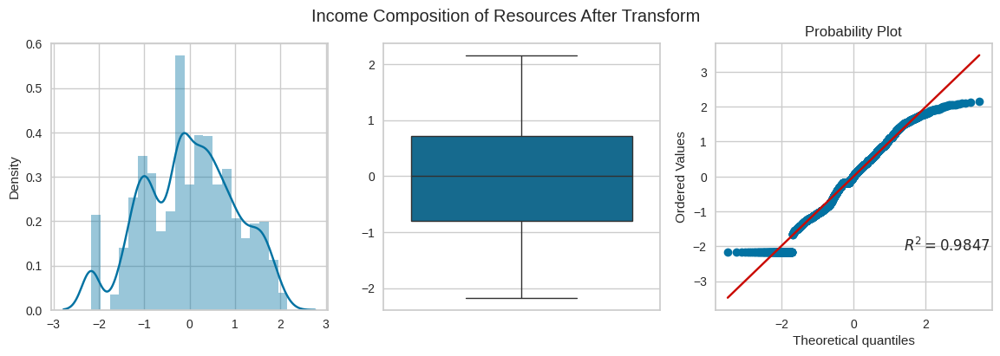

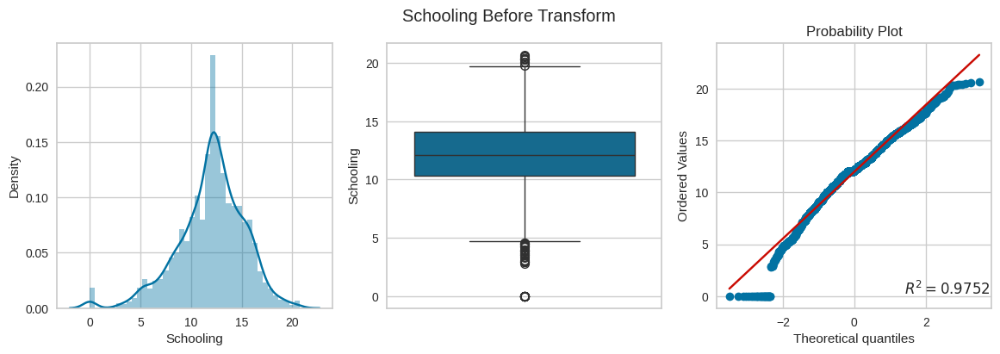

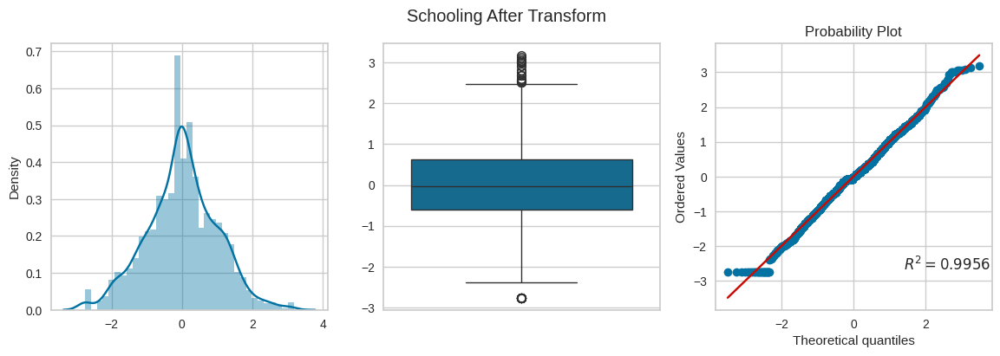

In [178]:
# Power Transform
for col in skewed_cols:
    apply_transform(PowerTransformer(),col)

Log Transform: Measles<br>
Square Transform: None <br>
Square Root Transform: None<br>
Reciprocal Transform: None <br>
Power Transform: Life Expectancy, Adult Mortality, Infant Deaths, Percentage Expenditure, Hepatitis B, Under-Five Deaths, Polio, Total Expenditure, Diphtheria, HIV/AIDS, GDP, Population, Thinness 1-19 Years, Thinness 5-9 Years, Schooling, Income Composition of Resources

### Outlier Treatment

In [179]:
def impute_outliers(data,col):
    winsorizer = Winsorizer(capping_method='iqr',fold=1.5,tail='both')
    fig = sns.boxplot(winsorizer.fit_transform(data[[col]]).values)
    plt.title(f"Box Plot of {col} after Outlier Removal")
    plt.show(fig)
    plt.close('all')
    del fig
    gc.collect()

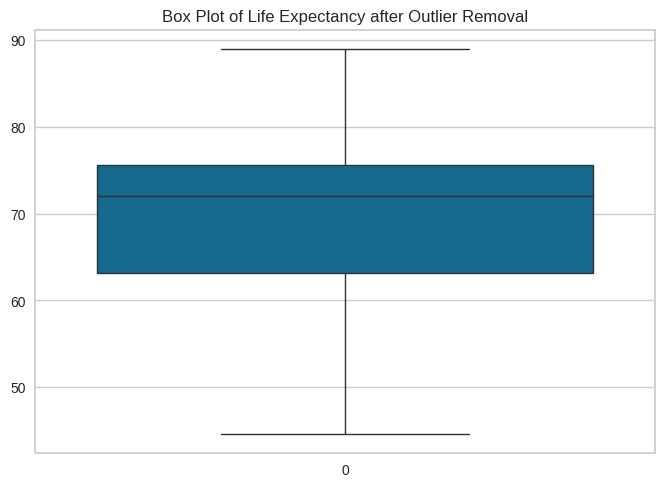

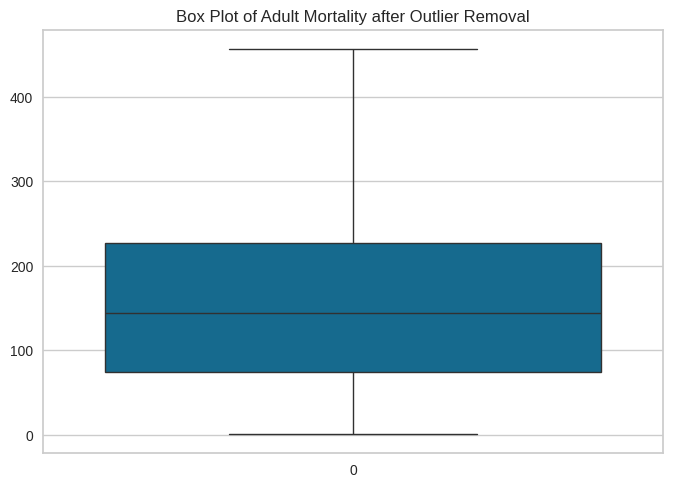

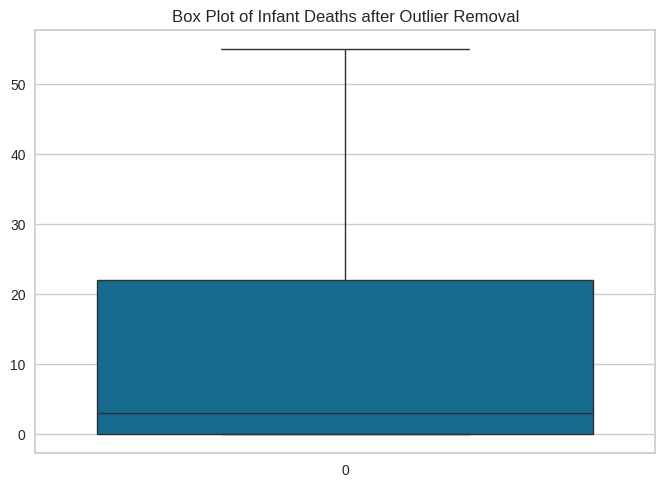

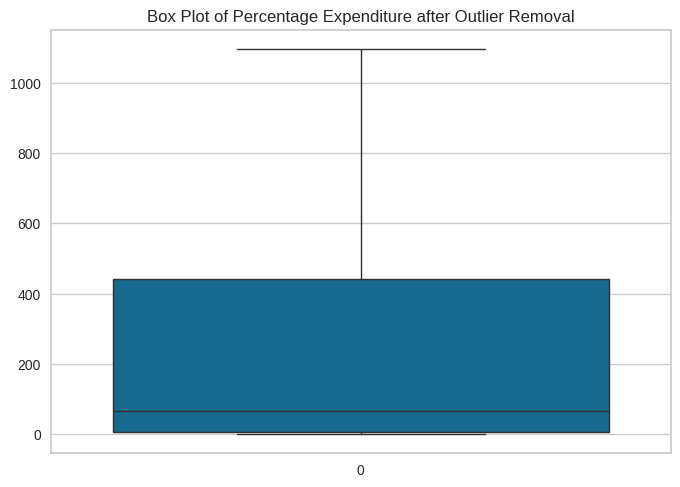

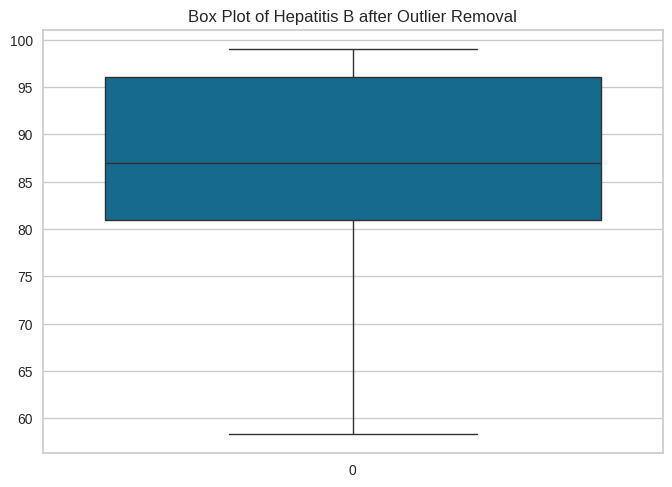

...

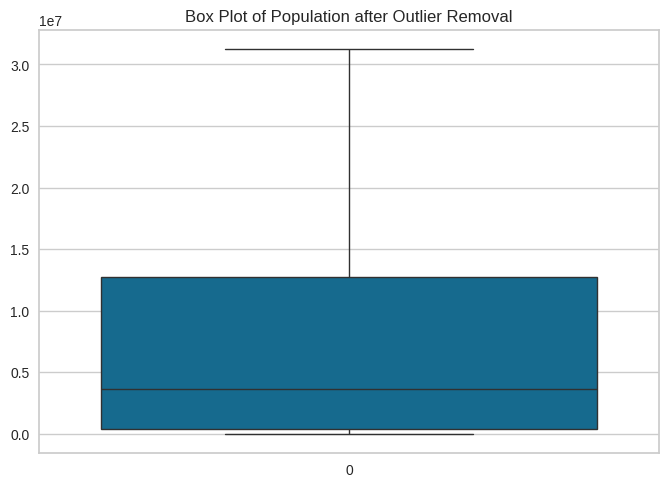

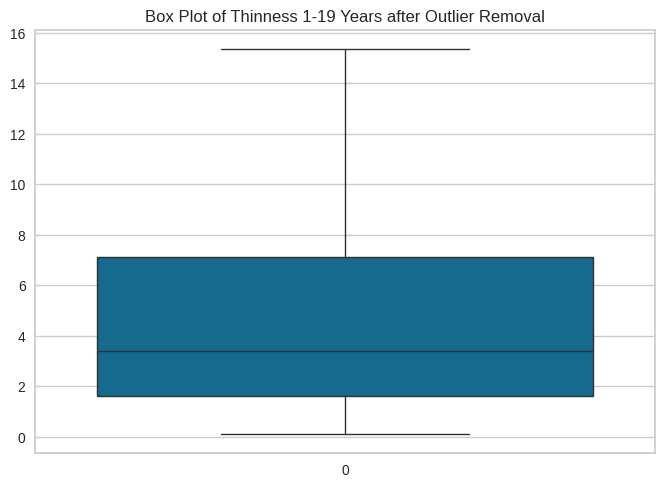

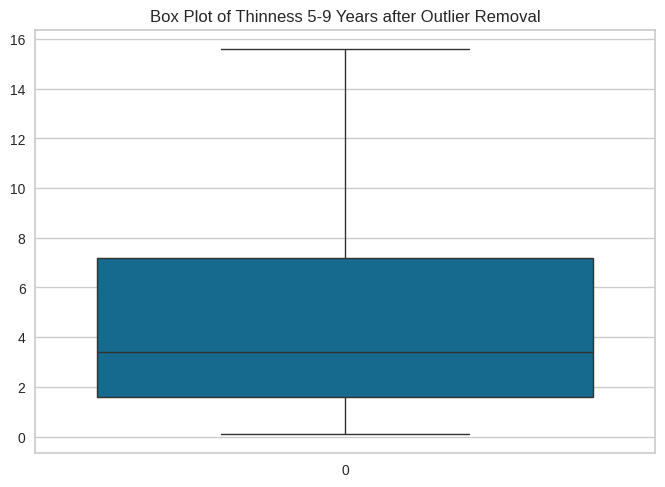

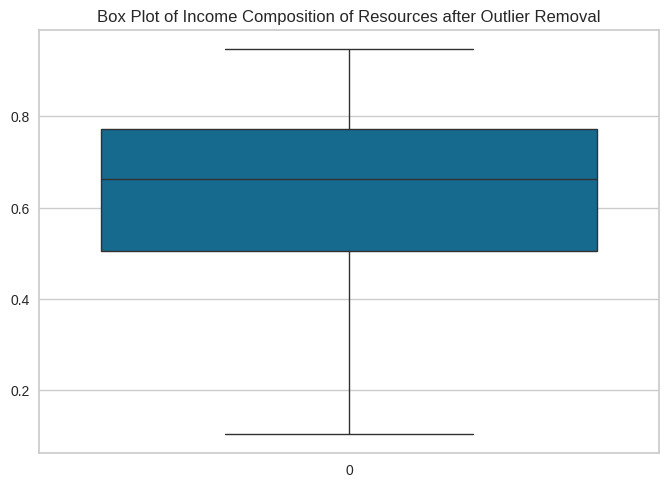

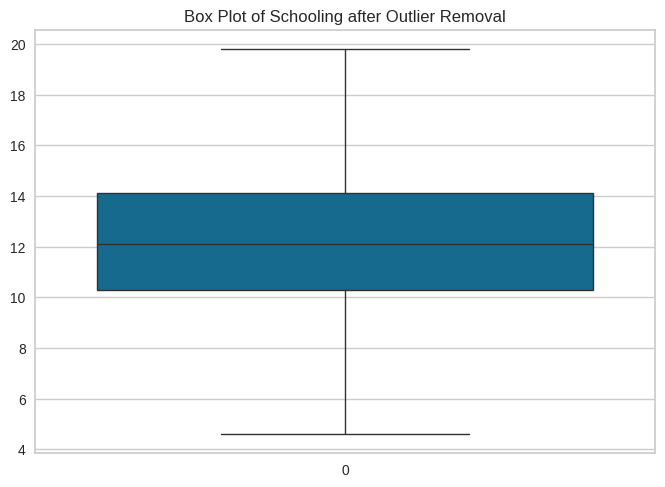

In [180]:
for col in skewed_cols:
    impute_outliers(df,col)

In [181]:
winsorizer = Winsorizer(capping_method='iqr',tail='both',fold=1.5)

for col in skewed_cols:
    df[col] = winsorizer.fit_transform(df[[col]])

### Categorical Encoding

In [182]:
status_encoder = OrdinalEncoder(categories=[['Developing','Developed']])
df['Status'] = status_encoder.fit_transform(df[['Status']])
df['Status'].sample(10)

,Status
1678,0.0
2068,1.0
870,0.0
2885,0.0
2786,0.0
2933,0.0
1189,0.0
1511,0.0
1540,1.0
614,0.0


In [183]:
status_mapping = {}

for idx, status in enumerate(status_encoder.categories_[0]):
    status_mapping[idx] = status

status_mapping

{0: 'Developing', 1: 'Developed'}

In [184]:
country_encoder = OneHotEncoder(drop='first',sparse_output=False,max_categories=10)
countries_encoded = country_encoder.fit_transform(df[['Country']])
countries_encoded = pd.DataFrame(countries_encoded,columns=country_encoder.get_feature_names_out())
countries_encoded.head()

,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Country_infrequent_sklearn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [185]:
df = pd.concat([df,countries_encoded],axis=1)
df.drop('Country',axis=1,inplace=True)
df.head()

,Year,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,BMI,...,Schooling,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Country_infrequent_sklearn
0,2015,0.0,65.0,263.0,55,0.01,71.279624,65.0,900.625,19.1,...,10.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2014,0.0,59.9,271.0,55,0.01,73.523582,62.0,492.000,18.6,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2013,0.0,59.9,268.0,55,0.01,73.219243,64.0,430.000,18.1,...,9.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2012,0.0,59.5,272.0,55,0.01,78.184215,67.0,900.625,17.6,...,9.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2011,0.0,59.2,275.0,55,0.01,7.097109,68.0,900.625,17.2,...,9.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Feature Splitting

In [186]:
X = df.drop('Life Expectancy',axis=1)
y = df['Life Expectancy']

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,shuffle=True,random_state=50)

## Feature Scaling

In [188]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled)

X_train_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.092862,-0.465969,0.678606,1.247160,-1.164395,-0.737617,-0.523924,-0.630084,-0.145156,1.172056,...,-1.159434,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,13.512340,-0.077046,-0.07084,-4.538506
1,-0.339643,-0.465969,0.486866,0.191710,-0.655614,-0.605007,-2.072692,-0.112864,-1.219607,0.133858,...,-0.640283,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
2,0.309114,-0.465969,-1.125492,-0.599877,1.034357,-0.602930,-0.445101,-0.650087,-0.280717,-0.584895,...,0.105996,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
3,0.092862,-0.465969,-1.291085,-0.547104,-0.824356,-0.600938,1.131346,-0.644372,0.808796,-0.584895,...,0.722487,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
4,-1.637157,-0.465969,0.329988,0.033393,-1.080025,-0.714591,-0.292150,-0.101434,-0.366071,-0.025865,...,-0.802518,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337


In [189]:
X_test_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,-0.772148,-0.465969,-0.977329,-0.230469,-0.514996,-0.737617,-0.292150,1.923509,-0.873172,-0.185588,...,-0.932306,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
1,-0.555895,2.146066,-1.273654,-0.705422,1.673529,2.086374,-0.292150,-0.650087,0.778672,-0.704687,...,1.371426,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
2,1.174124,-0.465969,0.040604,-0.705422,-1.172065,-0.737617,1.131346,-0.650087,1.943498,-0.704687,...,-0.026130,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
3,0.092862,-0.465969,-0.428256,-0.705422,1.113614,-0.671903,0.027833,-0.650087,0.532652,-0.704687,...,1.046957,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337
4,0.309114,-0.465969,-0.114500,-0.705422,1.660746,-0.737617,0.816057,-0.650087,0.221363,-0.704687,...,0.203337,-0.077046,-0.074006,-0.067528,-0.077046,-0.056459,-0.074006,-0.077046,-0.07084,0.220337


## Model Training & Evaluation

In [190]:
models = []
r2_scores = []
mae_scores = []
mape_scores = []
rmse_scores = []

In [191]:
def train_and_evaluate_model(model):

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R2 Score:", r2)
    print("Mean Absolute Error:", mae)
    print("Mean Absolute Percentage Error:", mape)
    print("Root Mean Squared Error:", rmse)

    models.append(model)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    rmse_scores.append(rmse)

    try:
        #prediction_error = PredictionError(estimator=model)
        #prediction_error.score(X_test_scaled, y_test)
        #prediction_error.show()

        #res_plot = ResidualsPlot(estimator=model)
        #res_plot.score(X_test_scaled, y_test)
        #res_plot.show()

        del r2, mae, mape, rmse

    except Exception as e:
        pass

    gc.collect()



In [192]:
train_and_evaluate_model(LinearRegression())

R2 Score: 0.854008402393691
Mean Absolute Error: 2.647209767139094
Mean Absolute Percentage Error: 0.041281190140982256
Root Mean Squared Error: 3.701807410772397


## Feature Selection

In [193]:
kbest = SelectKBest(k=10, score_func=f_regression)

kbest.fit(X_train_scaled, y_train)

selected_features = kbest.get_feature_names_out()

X_train_selected = kbest.transform(X_train_scaled)
X_test_selected = kbest.transform(X_test_scaled)

selected_features

array(['x2', 'x3', 'x8', 'x9', 'x10', 'x12', 'x13', 'x16', 'x18', 'x19'],
      dtype=object)

## Model Training & Evaluation after feature selection

In [194]:
models = []
r2_scores = []
mae_scores = []
mape_scores = []
rmse_scores = []

In [195]:
def train_and_evaluate_model(model):

    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R2 Score:", r2)
    print("Mean Absolute Error:", mae)
    print("Mean Absolute Percentage Error:", mape)
    print("Root Mean Squared Error:", rmse)

    models.append(model)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    rmse_scores.append(rmse)

    try:
        #prediction_error = PredictionError(estimator=model)
        #prediction_error.score(X_test_selected, y_test)
        #prediction_error.show()

        #res_plot = ResidualsPlot(estimator=model)
        #res_plot.score(X_test_selected, y_test)
        #res_plot.show()

        del r2, mae, mape, rmse

    except Exception as e:
        pass

    gc.collect()



In [196]:
train_and_evaluate_model(LinearRegression())

R2 Score: 0.8346781647978492
Mean Absolute Error: 2.903475840073993
Mean Absolute Percentage Error: 0.04518524585479588
Root Mean Squared Error: 3.9392631983052118


## Feature Selection with scikit-feature library

In [197]:
from sklearn.feature_selection import VarianceThreshold

# Initialize VarianceThreshold
selector = VarianceThreshold()

# Fit and transform the data
X_sele = selector.fit_transform(X_train)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_sele.shape)


redundant_cols = [col for col in X_train.columns if col not in X_train.columns[selector.get_support()]]
redundant_cols

Original shape: (2203, 29)
Reduced shape: (2203, 29)


[]

In [198]:
X_train_sf = selector.transform(X_train)
X_test_sf = selector.transform(X_test)

## Model Training & Evaluation after feature Selection with scikit-feature library

In [199]:
models = []
r2_scores = []
mae_scores = []
mape_scores = []
rmse_scores = []

In [200]:
def train_and_evaluate_model(model):

    model.fit(X_train_sf, y_train)

    y_pred = model.predict(X_test_sf)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R2 Score:", r2)
    print("Mean Absolute Error:", mae)
    print("Mean Absolute Percentage Error:", mape)
    print("Root Mean Squared Error:", rmse)

    models.append(model)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    rmse_scores.append(rmse)

    try:
        #prediction_error = PredictionError(estimator=model)
        #prediction_error.score(X_test_sf, y_test)
        #prediction_error.show()

        #res_plot = ResidualsPlot(estimator=model)
        #res_plot.score(X_test_sf, y_test)
        #res_plot.show()

        del r2, mae, mape, rmse

    except Exception as e:
        pass

    gc.collect()


In [201]:
train_and_evaluate_model(LinearRegression())

R2 Score: 0.8540084023910097
Mean Absolute Error: 2.647209767161993
Mean Absolute Percentage Error: 0.04128119014137615
Root Mean Squared Error: 3.7018074108063916


## Feature extraction with PCA

In [202]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)

print('shape of X_train_pca is: ', X_train_pca.shape)
print(pca.n_components_)

X_test_pca = pca.transform(X_test_scaled)

shape of X_train_pca is:  (2203, 21)
21


## Model Training & Evaluation after Feature Extraction with PCA

In [203]:
models = []
r2_scores = []
mae_scores = []
mape_scores = []
rmse_scores = []

In [204]:
def train_and_evaluate_model(model):

    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R2 Score:", r2)
    print("Mean Absolute Error:", mae)
    print("Mean Absolute Percentage Error:", mape)
    print("Root Mean Squared Error:", rmse)

    models.append(model)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    rmse_scores.append(rmse)

    try:
        #prediction_error = PredictionError(estimator=model)
        #prediction_error.score(X_test_pca, y_test)
        #prediction_error.show()

        #res_plot = ResidualsPlot(estimator=model)
        #res_plot.score(X_test_pca, y_test)
        #res_plot.show()

        del r2, mae, mape, rmse

    except Exception as e:
        pass

    gc.collect()



In [205]:
train_and_evaluate_model(LinearRegression())

R2 Score: 0.8404851592495651
Mean Absolute Error: 2.7499058356765107
Mean Absolute Percentage Error: 0.0427534394218269
Root Mean Squared Error: 3.8694606745457802


## Results

In [206]:
results = []

# All Features
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

results.append({
    'Method': 'All Features',
    'R2 Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
})


# SelectKBest
model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

results.append({
    'Method': 'SelectKBest',
    'R2 Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
})


# VarianceThreshold
model = LinearRegression()
model.fit(X_train_sf, y_train)
y_pred = model.predict(X_test_sf)

results.append({
    'Method': 'VarianceThreshold',
    'R2 Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
})


# PCA
model = LinearRegression()
model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)

results.append({
    'Method': 'PCA',
    'R2 Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
})


results = pd.DataFrame(results)

results

,Method,R2 Score,MAE,MAPE,RMSE
0,All Features,0.854008,2.647210,0.041281,3.701807
1,SelectKBest,0.834678,2.903476,0.045185,3.939263
2,VarianceThreshold,0.854008,2.647210,0.041281,3.701807
3,PCA,0.840485,2.749906,0.042753,3.869461
